In [1]:
!pip install diffusers transformers accelerate safetensors

  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 67.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 29.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 87.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 99.9 MB/s  0:00:00
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
Using cached accelerate-1.13.0-py3-none-any.whl (383 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.8/799.8 kB

In [2]:
!pip install torch torchvision torchaudio

In [1]:
import torch
from diffusers import StableDiffusionInpaintPipeline
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Ti


In [3]:
ORIGINAL_IMAGE_PATH = "/home/harry/Re_leaf_Project/Inpainting/original/Tomato Early Blight2.jpg"
MASK_IMAGE_PATH = "/home/harry/Re_leaf_Project/Inpainting/mask/Tomato Early Blight2.png"

OUTPUT_PATH = "/home/harry/Re_leaf_Project/Inpainting/output/result1.png"

In [64]:
image = Image.open(ORIGINAL_IMAGE_PATH).convert("RGB")
mask = Image.open(MASK_IMAGE_PATH).convert("RGB")

image = image.resize((768, 768))
mask = mask.resize((768, 768))

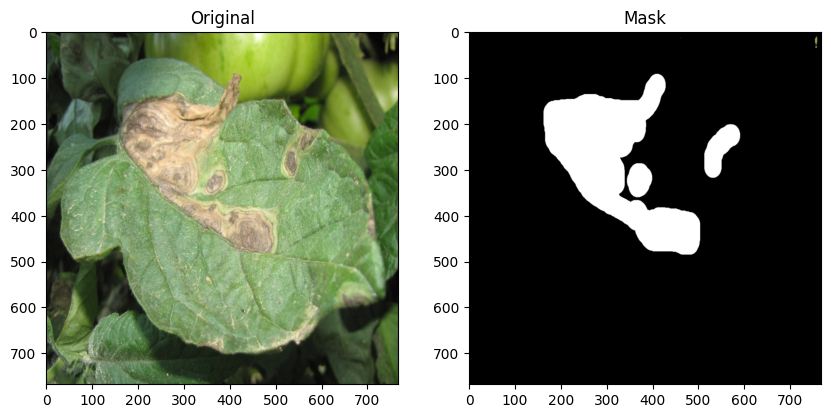

In [65]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

In [6]:
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -U diffusers transformers accelerate safetensors huggingface_hub

Looking in indexes: https://download.pytorch.org/whl/cu121


In [7]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.6.0+cu124
True
NVIDIA GeForce RTX 4060 Ti


In [8]:
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/harry/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/harry/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/harry/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/harry/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [66]:
result = pipe(
    prompt="""
    green leaf surface,
    preserve original image,
    minimal repair,
    natural texture continuity,
    maintain existing structure
    """,

    negative_prompt="""
    tomato fruit,
    folded leaf,
    artificial geometry,
    fake texture,
    paper texture,
    generated objects,
    hallucination,
    deformed veins
    """,

    image=image,
    mask_image=mask,

    strength=0.42,
    guidance_scale=4.5,
    num_inference_steps=60
).images[0]

  0%|          | 0/25 [00:00<?, ?it/s]

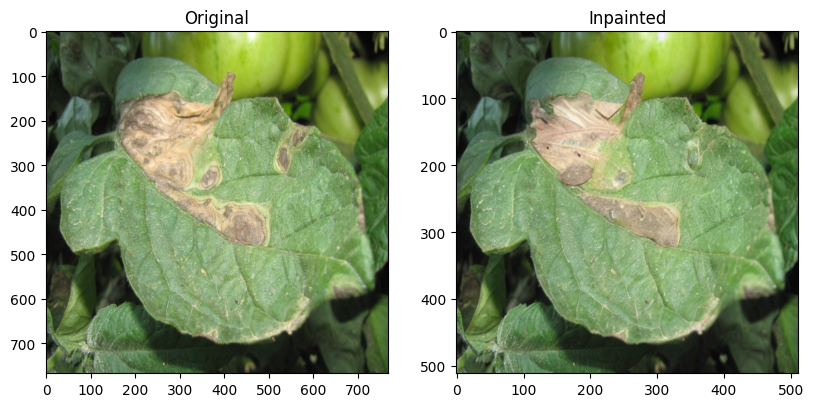

In [67]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(result)
plt.title("Inpainted")

plt.show()

In [52]:
result.save(OUTPUT_PATH)

print("저장 완료:", OUTPUT_PATH)

저장 완료: /home/harry/Re_leaf_Project/Inpainting/output/result1.png
